### FEM and device behaviour simulation

Here we try to use the physically derived conductivity parameters from VASP simulations into a continuum model solver. FEM is a natural and strong choice, see the theory part for algorithm and the theory we have used.

In [54]:
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from pathlib import Path
from matplotlib.tri import Triangulation

# Load DPT results
import sys
sys.path.append('../VASP/.')
from results_io import load_result
from uniaxial_model import UniaxialModel

sys.path.append('./FEM_Engine/src')
from fem import (make_mesh, element_geometry, assemble_2d,
                       solve_contacts, contact_currents, element_fields_2d,
                       cross_section_flux, device_resistance)



%matplotlib inline


As a test for the solver we can test a constant conductivity tensor, and have a look at the results. The functions are defined in `fem_aniso.py` for clarity and modularity, take a look at the implementation if they seem ambigous.


In [55]:
# Parameters
L = 1.0
Nx = 50
x = np.linspace(0, L, Nx)
sigma_values = 0.5 * np.ones(Nx-1) # The conductivity parameter

# Assemble full matrix
K_full, h = assemble_1d(sigma_values, L, Nx)

# Incorporate BC, and solve
V = solve_dirichlet(K_full, [0, Nx-1], [0.0, 1.0], n_nodes=Nx)

Now that we have the voltage values per element of the defined geometry, we can have further information regarding the more interesting quantities.

The interesting quanties are current which is constant since there is no change in 

V min/max: 0.0 1.0
Mean electric field: -1.0
Mean current density: -0.5


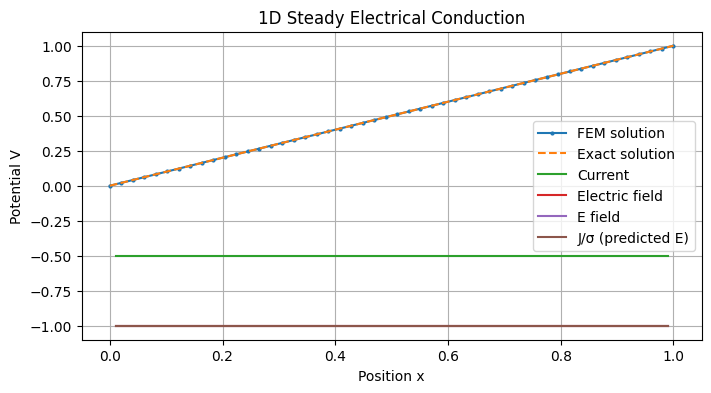

In [56]:

# ===POSTPROCESSING ====
x_mid = 0.5 * (x[:-1] + x[1:])          # element midpoints
# Derived quantities (BELLOW ARE FOR NODES)
E = -np.diff(V) / h # per elements
J = sigma_values * E # per elements

print("V min/max:", V.min(), V.max())
print("Mean electric field:", np.mean(E))
print("Mean current density:", np.mean(J))

# Exact solution1
V_exact = x / L

# Plot
plt.figure(figsize=(8, 4))
plt.plot(x, V, '-o', markersize=2,label='FEM solution', )
plt.plot(x, V_exact, '--', label='Exact solution')
plt.plot(x_mid, J, label='Current')
plt.plot(x_mid, E, label='Electric field')
plt.step(x_mid, E, where='mid', label='E field')
plt.step(x_mid, J.mean() / sigma_values, where='mid', label='J/σ (predicted E)')
# these two should lie exactly on top of each other
plt.xlabel('Position x')
plt.ylabel('Potential V')
plt.title('1D Steady Electrical Conduction')
plt.grid(True)
plt.legend()
plt.show()

### Plugging in the hydrostatic results

The $\Gamma_1$ channel is loaded from `Hydrostatic_scalars.csv`, which the DFT
pipeline wrote. Two quantities come across — the gap deformation potential
$a_\text{gap}$ and the tangent coefficient $\pi_\text{eff}$ — and both are
referenced to **linear** hydrostatic strain. An assertion checks that
$\pi_\text{eff} = -a_\text{gap}/2k_BT$ before anything else runs, because the
literature value in `DPT_results.csv` uses the volumetric convention and is
smaller by a factor of three; mixing the two silently produces a "tangent" line
that is not tangent.

Three functions are defined:

| function | role |
|---|---|
| `sigma_phys(eps)` | $\sigma_0\exp(-a_\text{gap}\varepsilon/2k_BT)$ — the first-principles law |
| `sigma_lin(eps)` | $\sigma_0(1+\pi_\text{eff}\varepsilon)$ — its tangent at $\varepsilon=0$ |
| `solve_1d(sigma)` | assembles $K$ from the per-element conductivities, applies the Dirichlet contacts, returns $V$, $E$ and $J$ |

`solve_1d` refuses any input containing $\sigma \le 0$: a non-positive
conductivity makes the stiffness matrix indefinite, and the solver would return
a number rather than an error. Experiment 2 depends on that guard.

#### Experiment 1 — a localised strain field

A point load at a cantilever tip, or the edge of a pressurised diaphragm,
concentrates strain over a short length of the conductor. That is imposed here
as `eps_field`, a Gaussian of $1\%$ peak tensile strain centred at $x=0.35$.
Each element's conductivity is evaluated from its own local strain, the system
is assembled and solved for the potential, and $E=-\nabla V$ and $J=\sigma E$
are recovered by post-processing.

Since the domain is one-dimensional and hydrostatic strain preserves cubic
symmetry, $\sigma$ stays a scalar here.

#### Experiment 2 — the cost of linearising

The same strain shape is pushed through both constitutive laws over a range of
load amplitudes, and the total device resistance $R = V_\text{applied}/I$ is
compared. Because the two laws are tangent at $\varepsilon = 0$ by construction,
any divergence is attributable to the exponential's curvature and nothing else.


Constitutive law
--------------------------------------------------------------
  a_gap    = +5.4864 eV   (per unit LINEAR strain)
  pi_eff   = -106.11     (tangent, verified)
  sigma_lin reaches ZERO at eps = 0.942%
  -> beyond that the linear model predicts NEGATIVE conductivity,
     which is not merely inaccurate: it makes the FEM system
     indefinite and the solve meaningless.

Experiment 1 -- localised strain field
--------------------------------------------------------------
  sigma range          0.34989 .. 1.00000
  current J   mean =   -0.833800
              std  =   1.826e-14
              std/mean = 2.19e-14   (conserved)

Experiment 2 -- linearisation error vs applied load
--------------------------------------------------------------
  peak strain 0.00%  ->    +0.00%
  peak strain 0.25%  ->    +0.62%
  peak strain 0.50%  ->    +3.91%
  peak strain 0.75%  ->   +18.12%
  peak strain 1.00%  ->      n/a   <- sigma_lin <= 0, model unphysical
  peak strain 1.25%  ->      n/

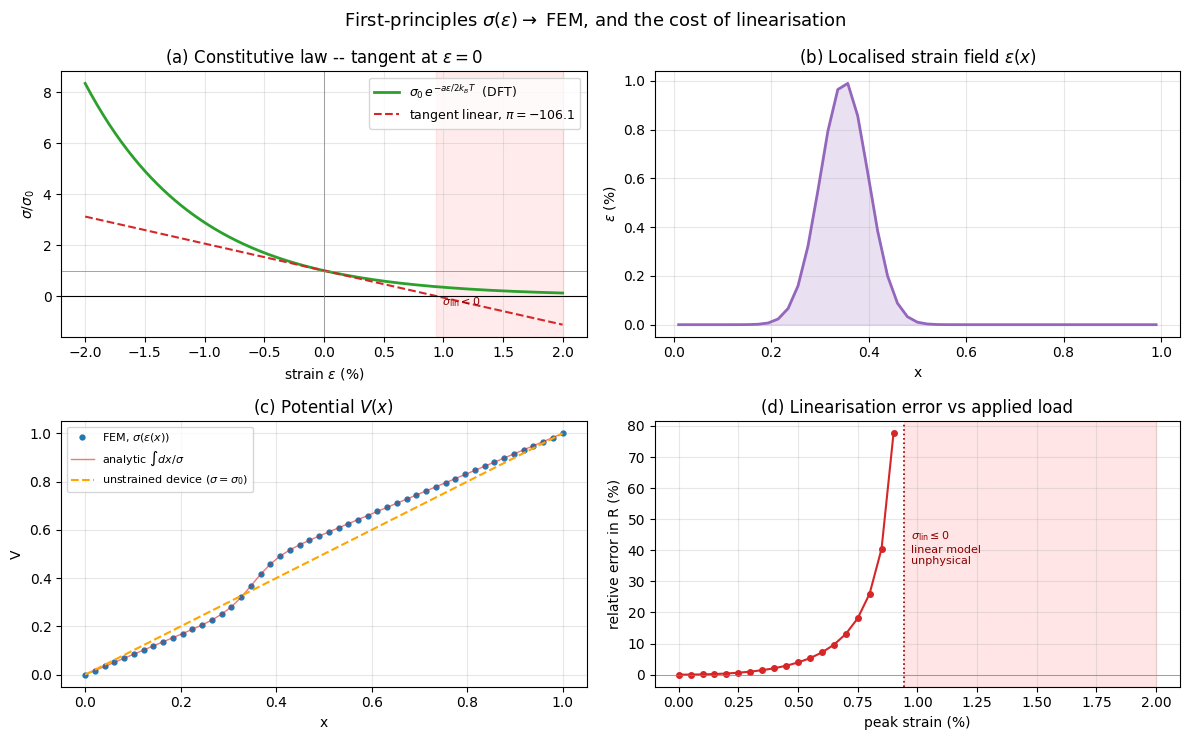

In [ ]:
HYDRO = "../VASP/Hydrostatic_strain/Hydrostatic_scalars.csv"

# =====================================================================
#  Constitutive law
# =====================================================================
a_dp   = load_result("a_gap",  HYDRO)      # eV, per unit LINEAR strain
pi_eff = load_result("pi_eff", HYDRO)      # per unit LINEAR strain
T      = load_result("T",      HYDRO)
KB     = 8.617333262e-5
KT     = KB * T

# A quick check on derived quantities from hydrostatic run
assert np.isclose(pi_eff, -a_dp / (2 * KT), rtol=1e-6), (
    f"pi_eff ({pi_eff:.3f}) is not the tangent of the exponential law with "
    f"a_dp = {a_dp:.4f} eV (expected {-a_dp/(2*KT):.3f}). "
    "The two are on different strain conventions -- do not proceed."
)


def sigma_phys(eps, sigma0=1.0):
    """First-principles conductivity. `eps` is LINEAR hydrostatic strain."""
    eps = np.atleast_1d(eps).astype(float)
    return sigma0 * np.exp(-a_dp * eps / (2 * KT))


def sigma_lin(eps, sigma0=1.0):
    """Tangent linear piezoresistor -- same slope at eps = 0 by construction."""
    eps = np.atleast_1d(eps).astype(float)
    return sigma0 * (1 + pi_eff * eps)


# --- where the LINEAR model stops being physical at all ---
EPS_NEG = -1.0 / pi_eff          # sigma_lin <= 0 beyond this strain

print("Constitutive law")
print("-" * 62)
print(f"  a_gap    = {a_dp:+.4f} eV   (per unit LINEAR strain)")
print(f"  pi_eff   = {pi_eff:+.2f}     (tangent, verified)")
print(f"  sigma_lin reaches ZERO at eps = {EPS_NEG*100:.3f}%")
print("  -> beyond that the linear model predicts NEGATIVE conductivity,")
print("     which is not merely inaccurate: it makes the FEM system")
print("     indefinite and the solve meaningless.")


# =====================================================================
#  Domain -- defined BEFORE anything is assembled
# =====================================================================
L, Nx = 1.0, 50
x  = np.linspace(0, L, Nx)
xm = 0.5 * (x[:-1] + x[1:])              # element midpoints
SIGMA0 = 1.0

# params for solver
V_LEFT, V_RIGHT = 0.0, 1.0
FIXED = [0, Nx - 1]
VALS  = [V_LEFT, V_RIGHT]


def solve_1d(sigma_elements):
    """Assemble and solve for a given per-element conductivity. Returns V, h, J."""
    sigma_elements = np.asarray(sigma_elements, float)
    if np.any(sigma_elements <= 0):
        raise ValueError(
            f"non-positive conductivity in {np.sum(sigma_elements <= 0)} element(s) "
            f"(min = {sigma_elements.min():.4f}); the FEM system is not "
            f"positive-definite and the solution would be meaningless"
        )
    K, h = assemble_1d(sigma_elements, L, Nx)
    V    = solve_dirichlet(K, FIXED, VALS, n_nodes=Nx)
    E    = -np.diff(V) / h
    J    = sigma_elements * E
    return V, h, J


# =====================================================================
#  EXPERIMENT 1 -- physical sigma(x) from a localised strain field
#  (a stress concentration, as at a cantilever anchor or diaphragm edge)
# =====================================================================
eps_field = 0.010 * np.exp(-((xm - 0.35) / 0.07) ** 2)     # 1% peak, tensile
sigma_e   = sigma_phys(eps_field, SIGMA0)

V, h, J = solve_1d(sigma_e)                                # assembled from sigma_e

print("\nExperiment 1 -- localised strain field")
print("-" * 62)
print(f"  sigma range          {sigma_e.min():.5f} .. {sigma_e.max():.5f}")
print(f"  current J   mean =   {J.mean():.6f}")
print(f"              std  =   {J.std():.3e}")
print(f"              std/mean = {J.std()/abs(J.mean()):.2e}   (conserved)")

assert J.std() / abs(J.mean()) < 1e-10, "current not conserved -- check assembly"


# =====================================================================
#  EXPERIMENT 2 -- linearisation error vs applied load
#  Same strain shape into both laws; compare total device resistance.
# =====================================================================
def total_resistance(sigma_func, peak):
    """R = V_applied / I for a Gaussian strain bump of the given amplitude.
    Returns NaN if the constitutive law produced a non-physical sigma."""
    eps = peak * np.exp(-((xm - 0.5) / 0.1) ** 2)
    s   = sigma_func(eps, SIGMA0)
    if np.any(s <= 0):
        return np.nan
    _, _, J = solve_1d(s)
    return (V_RIGHT - V_LEFT) / abs(J.mean())


loads   = np.linspace(0.0, 0.02, 41)
R_lin   = np.array([total_resistance(sigma_lin,  p) for p in loads])
R_phys  = np.array([total_resistance(sigma_phys, p) for p in loads])
divergence = (R_lin - R_phys) / R_phys * 100.0

valid   = np.isfinite(divergence)
n_bad   = int((~valid).sum())

print("\nExperiment 2 -- linearisation error vs applied load")
print("-" * 62)
for p, d in zip(loads[::5], divergence[::5]):
    flag = "" if np.isfinite(d) else "   <- sigma_lin <= 0, model unphysical"
    val  = f"{d:+7.2f}%" if np.isfinite(d) else "    n/a"
    print(f"  peak strain {p*100:4.2f}%  ->  {val}{flag}")

if n_bad:
    print(f"\n  {n_bad} of {len(loads)} load points rejected: the linear model")
    print(f"  predicts sigma <= 0 above eps = {EPS_NEG*100:.3f}%.")
    print("  This is the headline result, not a numerical failure -- the")
    print("  linearisation does not merely lose accuracy, it leaves the")
    print("  physical domain entirely.")


# =====================================================================
#  FIGURE
# =====================================================================
fig, ax = plt.subplots(2, 2, figsize=(12, 7.5))

# (a) the two laws
es = np.linspace(-0.02, 0.02, 400)
ax[0, 0].plot(es*100, sigma_phys(es, 1.0), '-', color='tab:green', lw=2,
              label=r'$\sigma_0\,e^{-a\varepsilon/2k_BT}$  (DFT)')
ax[0, 0].plot(es*100, sigma_lin(es, 1.0), '--', color='tab:red', lw=1.5,
              label=rf'tangent linear, $\pi={pi_eff:.1f}$')
ax[0, 0].axhline(0, color='k', lw=0.8)
ax[0, 0].axhline(1, color='gray', lw=0.5); ax[0, 0].axvline(0, color='gray', lw=0.5)
ax[0, 0].axvspan(EPS_NEG*100, 2.0, color='red', alpha=0.08)
ax[0, 0].text(EPS_NEG*100 + 0.05, -0.35, r'$\sigma_{\rm lin}<0$',
              fontsize=8, color='darkred')
ax[0, 0].set(title=r"(a) Constitutive law -- tangent at $\varepsilon=0$",
             xlabel=r"strain $\varepsilon$ (%)", ylabel=r"$\sigma/\sigma_0$")
ax[0, 0].legend(fontsize=9); ax[0, 0].grid(alpha=0.3)

# (b) the strain field
ax[0, 1].plot(xm, eps_field*100, color='tab:purple', lw=2)
ax[0, 1].fill_between(xm, 0, eps_field*100, alpha=0.2, color='tab:purple')
ax[0, 1].set(title=r"(b) Localised strain field $\varepsilon(x)$",
             xlabel="x", ylabel=r"$\varepsilon$ (%)")
ax[0, 1].grid(alpha=0.3)

# --- panel (c) ---
# for this 1d case we can have analytical solutio as well
_inv = lambda t: 1.0 / sigma_phys(0.010*np.exp(-((t-0.35)/0.07)**2))[0]
_den = quad(_inv, 0, L, limit=400)[0]
V_exact = np.array([quad(_inv, 0, xi, limit=400)[0] / _den for xi in x])

ax[1, 0].plot(x, V, 'o', ms=3.5, color='tab:blue', label=r'FEM, $\sigma(\varepsilon(x))$')
ax[1, 0].plot(x, V_exact, '-', color='tab:red', lw=1, alpha=0.6,
              label=r'analytic $\int dx/\sigma$')
ax[1, 0].plot(x, V_LEFT + (V_RIGHT-V_LEFT)*x/L, '--', color='orange',
              label=r'unstrained device ($\sigma=\sigma_0$)')
ax[1, 0].set(title=r"(c) Potential $V(x)$", xlabel="x", ylabel="V")
ax[1, 0].legend(fontsize=8); ax[1, 0].grid(alpha=0.3)

# (d) divergence
ax[1, 1].plot(loads[valid]*100, divergence[valid], '-o', ms=4, color='tab:red')
ax[1, 1].axhline(0, color='gray', lw=0.5)
if n_bad:
    ax[1, 1].axvspan(EPS_NEG*100, loads.max()*100, color='red', alpha=0.10)
    ax[1, 1].axvline(EPS_NEG*100, color='darkred', ls=':', lw=1.2)
    ax[1, 1].text(EPS_NEG*100, ax[1, 1].get_ylim()[1]*0.5,
                  r'  $\sigma_{\rm lin}\leq 0$' '\n  linear model' '\n  unphysical',
                  fontsize=8, color='darkred', va='center')
ax[1, 1].set(title="(d) Linearisation error vs applied load",
             xlabel="peak strain (%)", ylabel="relative error in R (%)")
ax[1, 1].grid(alpha=0.3)

plt.suptitle(r"First-principles $\sigma(\varepsilon)\rightarrow$ FEM, "
             r"and the cost of linearisation", fontsize=13)
plt.tight_layout()
# fig.savefig("figures/seminar_results.pdf", bbox_inches="tight")
plt.show()


Whether any of this means anything depends first on whether the solve is right, and
in one dimension that can be settled outright rather than argued. Charge
conservation forces $J$ to be constant, so $dV/dx = J/\sigma$ and the potential is
just the running integral of $1/\sigma$ normalised to the applied bias. Evaluating
that by quadrature gives $R = 1.199326$ and $J = 0.833801$; the FEM returns the same
numbers, with nodal agreement of $3\times10^{-4}$ at fifty elements improving by a
factor of four for each halving of the mesh — the second-order convergence P1
elements are supposed to deliver. Current conservation to $2\times10^{-14}$ comes
along with it, but on its own that proves less than it looks like: in 1D
$\nabla\!\cdot\!J = 0$ holds however $\sigma$ is distributed, so it tests the
assembly rather than the physics. The agreement with the closed form is the check
that actually constrains anything.

With that settled, panel (c) shows the mechanism running end to end. Tensile strain
widens the gap, since $a_\text{gap}$ is positive; a wider gap leaves fewer carriers
thermally excited across it; fewer carriers mean lower conductivity, and at the peak
of the imposed Gaussian $\sigma$ has fallen to $0.350\,\sigma_0$. Because $J$ is the
same everywhere, the gradient must steepen wherever $\sigma$ drops, and that is the
kink near $x\approx0.35$. Past the bump $\sigma$ recovers and the slope settles back
to $J = 0.834$, now permanently offset above the unstrained reference line, whose
slope is $1$; the two meet again at $x=1$ only because the contact pins them there.
A strained region occupying under a fifth of the length raises the device resistance
by $19.9\%$.

The second experiment asks what that same field costs if the exponential is replaced
by its tangent. The two laws agree to first order by construction, so whatever
separates them is curvature and nothing else. The error in $R$ climbs much faster
than the strain driving it — $0.08\%$ at $0.1\%$ peak strain, $0.62\%$ at $0.25\%$,
$3.9\%$ at $0.5\%$, $18\%$ at $0.75\%$, $78\%$ at $0.9\%$ — but extrapolating that
trend misses the more interesting failure, which is that the linear law runs out of
physics before it runs out of accuracy. $\sigma_\text{lin} = \sigma_0(1+\pi\varepsilon)$
reaches zero at $\varepsilon = 1/|\pi_\text{eff}| = 0.942\%$ and turns negative
beyond it. A negative conductivity is not a poor approximation to a small one; it
takes the stiffness matrix out of positive-definiteness, and the solver then returns
a number that means nothing. Twenty-two of the forty-one load points are rejected on
that basis rather than plotted.

How much of this matters depends on where the device sits. At the $\sim0.1\%$ strains
a MEMS piezoresistor normally works at, the linear model is accurate to better than a
tenth of a percent and the usual $\pi$-coefficient treatment is entirely adequate —
nothing here argues otherwise. The divergence bites at stress concentrations near
anchors and diaphragm edges, where local strain can approach $1\%$ while the nominal
device strain stays small, and in over-range or failure analysis. Those are also
exactly the cases where a linear model gives no indication that it has stopped
applying: it returns a finite resistance at every strain, including strains at which
it has quietly predicted that current flows the wrong way.

All of this characterises the $\Gamma_1$ channel, whose mechanism is carrier density.
In doped silicon the carrier concentration is pinned by the dopants and this channel
is strongly suppressed, so what is measured above is intrinsic material.
$\pi_{11}$ and $\pi_{12}$ arise from a different mechanism — valley repopulation at
fixed carrier number — and belong to the $\Gamma_{12}$ channel.

## 2D domains

The finite element method comes into its own on 2D domains: it handles
irregular geometry and mixed boundary conditions on an unstructured mesh,
where a finite-difference grid would have to be fitted to the shape.

The mesh, assembly, boundary and post-processing routines live in the helper
`fem_aniso.py`. The material parameters come from the DFT pipeline, and two
quantities are formed here:

- `C_EXP` $= a_\text{vol}/2k_BT \approx 35.4$ — the exponent prefactor of the
  conductivity law. It is the strain sensitivity per unit **volumetric**
  strain, and equals $|\pi_\text{eff}|/3$, since $\pi_\text{eff}$ is referenced
  to linear strain.
- `NU_SI` — Poisson's ratio, taken from $C_{12}/(C_{11}+C_{12})$ in the
  uniaxial results. It converts the imposed axial strain to the volumetric
  strain the $\Gamma_1$ channel actually responds to,
  $\varepsilon_h = (1-2\nu)\,\varepsilon_{xx}$.

The conductivity laws have the same form as in 1D, but are re-declared here
against $\varepsilon_h$ and $a_\text{vol}$. The 1D versions cannot be called
directly: they were built on $a_\text{gap}$, which is referenced to linear
strain and is three times larger.

In [58]:
"""
Loading the inputs
"""
# ----------------------------------------------------------------------
# Material parameters
# ----------------------------------------------------------------------
def load_material(hydro_csv="../VASP/Hydrostatic_strain/Hydrostatic_scalars.csv",
                  uni_csv="../VASP/Uniaxial_strain/uniaxial_scalars.csv"):
    KB = 8.617333262e-5
    a_vol, T, nu = 1.83, 300.0, 0.27
    
    try:
        from results_io import load_result
    except ImportError:
        print("  ! results_io not importable -- using fallback values")
        return a_vol, T, nu, KB

    if os.path.exists(hydro_csv):
        a_vol = load_result("a_vol", hydro_csv)
        T = load_result("T", hydro_csv)
        try:
            a_gap = load_result("a_gap", hydro_csv)
            assert abs(a_gap / a_vol - 3.0) < 0.05, (
                f"a_gap/a_vol = {a_gap/a_vol:.3f}, expected 3.")
        except KeyError:
            pass

    if os.path.exists(uni_csv):
        nu = load_result("nu", uni_csv)

    print(f"  a_vol = {a_vol:.4f} eV, T = {T:.1f} K, nu = {nu:.4f}")
    return a_vol, T, nu, KB


A_VOL, T_K, NU_SI, KB = load_material()
KB_T = KB * T_K
C_EXP = A_VOL / (2.0 * KB_T)
SIGMA0 = 1.0
print(f"  C_EXP = {C_EXP:.2f}\n")

def bending_strain(centroids, L, H, eps_root):
    """eps_xx at element centroids; eps_root = surface strain at the root."""
    xc, yc = centroids[:, 0], centroids[:, 1]
    y_n = H / 2.0
    eps_xx = eps_root * (L - xc) / L * (yc - y_n) / (H / 2.0)
    eps_h = (1.0 - 2.0 * NU_SI) * eps_xx
    return eps_xx, eps_h


def centroids_of(points, triangles):
    """Element centroids."""
    return element_geometry(points, triangles)[2]

def sigma_deformation_potential(eps_h):
    """sigma0 * exp(-a_vol * eps_h / 2kT).  eps_h is VOLUMETRIC strain."""
    return SIGMA0 * np.exp(-C_EXP * np.asarray(eps_h, float))

def sigma_linear_tangent(eps_h):
    """Tangent at eps = 0, so any difference is nonlinearity, not a
    coefficient mismatch."""
    return SIGMA0 * (1.0 - C_EXP * np.asarray(eps_h, float))

  a_vol = 1.8288 eV, T = 300.0 K, nu = 0.2871
  C_EXP = 35.37



# Validation Suite: Making Sure Our Solver Works

If the solver passes these tests, we can trust it.


We start with a simple rectangular domain (length L=1.0, height H=0.2) and discretize it into a mesh of triangles. This is our "computational canvas" where we'll paint different conductivity patterns and see if our solver paints the right voltage picture. (panel 3)

## Test 1: (Uniform Conductivity)

First, we assume the material has the same conductivity everywhere. In this case, the voltage should drop linearly from 1 volt on the left to 0 volts on the right. We check three things:
- Is the voltage exactly linear? (It should be)
- Does current entering equal current leaving? (Conservation of charge)
- Does the resistance match the simple formula R = L/(σH)? 

## Test 2: Varying Along the Length (σ depends on x)

Now what if conductivity varies along the length, like σ(x) = 1 + x²? For this specific variation, we can actually calculate the resistance analytically using calculus (1D cumulative integral). We compare our 2D numerical result with this exact 1D formula. If they match, our 2D solver correctly handles x-dependent properties.

## Test 3: Bending (σ depends on y)

When we have pure bending (uniform moment), the top gets stretched (tension) and the bottom gets compressed. The deformation-potential model says conductivity changes exponentially with strain. So conductivity becomes higher in the compressed region (bottom) and lower in tension (top). We can calculate the exact resistance for this y-dependent conductivity using an integral across the height. Our numerical result should match this analytical formula.

## Test 4: The Linear Model Test

If we use a linear approximation of conductivity (instead of exponential), the changes in conductivity should average out because the strain is antisymmetric - positive on top, negative on bottom. The linear term cancels exactly, so resistance should be unchanged from the uniform case. If our solver shows any resistance change here, something's wrong.

## Why This Matters

These four tests verify every piece of our solver:
- **Mesh generation** (can we represent the geometry?)
- **Assembly** (can we build the stiffness matrix correctly?)
- **Boundary conditions** (can we apply voltage at the contacts?)
- **Solver** (can we solve the linear system accurately?)
- **Physics** (does the deformation-potential model behave as expected?)

Passing all four with high accuracy gives us confidence to use this solver for real device simulations where there's no analytical answer to check against.

## TL;DR

We're testing our solver against four known problems. If it passes all four, it means our code is correct.

In [59]:

# ======================================================================
# VALIDATION SUITE
# ======================================================================
def run_validations():
    print("=" * 64)
    print("VALIDATION")
    print("=" * 64)
    
    L, H, nx, ny = 1.0, 0.2, 81, 17
    points, triangles = make_mesh(L, H, nx, ny)
    centro = centroids_of(points, triangles)
    nE = len(triangles)
    R0_exact = L / (SIGMA0 * H)

    # V1: uniform sigma -> exact linear potential
    sigma_u = SIGMA0 * np.ones(nE)
    K = assemble_2d(points, triangles, sigma_u)
    V, lft, rgt = solve_contacts(K, points, L, V_left=1.0, V_right=0.0)
    err = np.max(np.abs(V - (1.0 - points[:, 0] / L)))
    I_l, I_r = contact_currents(K, V, lft, rgt)
    R_num = device_resistance(K, V, lft, rgt)
    print(f"[V1] uniform sigma : max|V - V_exact| = {err:.3e}")
    print(f"[V1] conservation  : |I_in + I_out|/|I_in| = {abs(I_l + I_r)/abs(I_l):.3e}")
    print(f"[V1] resistance    : R_num = {R_num:.6f},  L/(sigma0 H) = {R0_exact:.6f}\n")

    # V2: sigma = sigma(x) -> 1D cumulative-inverse formula
    sigma_x = 1.0 + centro[:, 0] ** 2
    K = assemble_2d(points, triangles, sigma_x)
    V, lft, rgt = solve_contacts(K, points, L)
    I_l, I_r = contact_currents(K, V, lft, rgt)
    R_num = device_resistance(K, V, lft, rgt)
    R_1d = (1.0 / H) * (np.pi / 4.0)
    print(f"[V2] sigma(x)=1+x^2: R_2D = {R_num:.6f},  R_1D(cumulative) = {R_1d:.6f}")
    print(f"[V2] rel.err = {abs(R_num - R_1d)/R_1d:.3e}")
    print(f"[V2] conservation  : |I_in + I_out|/|I_in| = {abs(I_l + I_r)/abs(I_l):.3e}\n")

    # V3: pure bending, sigma = sigma(y) -> R = L / int sigma dy
    eps_xx = 5e-3 * (centro[:, 1] - H / 2) / (H / 2)
    eps_h = (1 - 2 * NU_SI) * eps_xx
    K = assemble_2d(points, triangles, sigma_deformation_potential(eps_h))
    V, lft, rgt = solve_contacts(K, points, L)
    R_num = device_resistance(K, V, lft, rgt)
    c = C_EXP * (1 - 2 * NU_SI) * 5e-3
    G_exact = SIGMA0 * H * np.sinh(c) / c
    R_exact = L / G_exact
    print(f"[V3] sigma(y) bend : R_2D = {R_num:.6f},  analytic = {R_exact:.6f}")
    print(f"[V3] rel.err = {abs(R_num - R_exact)/R_exact:.3e}\n")

    # V4: the linear model cancels exactly under antisymmetric bending
    K = assemble_2d(points, triangles, sigma_linear_tangent(eps_h))
    V, lft, rgt = solve_contacts(K, points, L)
    R_lin = device_resistance(K, V, lft, rgt)
    print(f"[V4] linear law    : R_2D = {R_lin:.6f},  R0 = {R0_exact:.6f}")
    print(f"[V4] dR/R0 = {(R_lin - R0_exact)/R0_exact:+.3e}")
    print("     (the linear term is odd in y and integrates to zero)\n")



VALIDATION
[V1] uniform sigma : max|V - V_exact| = 3.197e-14
[V1] conservation  : |I_in + I_out|/|I_in| = 2.161e-13
[V1] resistance    : R_num = 5.000000,  L/(sigma0 H) = 5.000000

[V2] sigma(x)=1+x^2: R_2D = 3.926993,  R_1D(cumulative) = 3.926991
[V2] rel.err = 5.932e-07
[V2] conservation  : |I_in + I_out|/|I_in| = 1.805e-13

[V3] sigma(y) bend : R_2D = 4.995290,  analytic = 4.995278
[V3] rel.err = 2.461e-06

[V4] linear law    : R_2D = 5.000000,  R0 = 5.000000
[V4] dR/R0 = +1.782e-13
     (the linear term is odd in y and integrates to zero)

DEMO  (cantilever, eps_root = 8.0e-03)
sigma min/max      : 0.8900 / 1.1239
I_in, I_out        : +0.200158, -0.200158
conservation       : 5.55e-15
R, R0, dR/R0       : 4.996049, 5.000000, -7.9024e-04



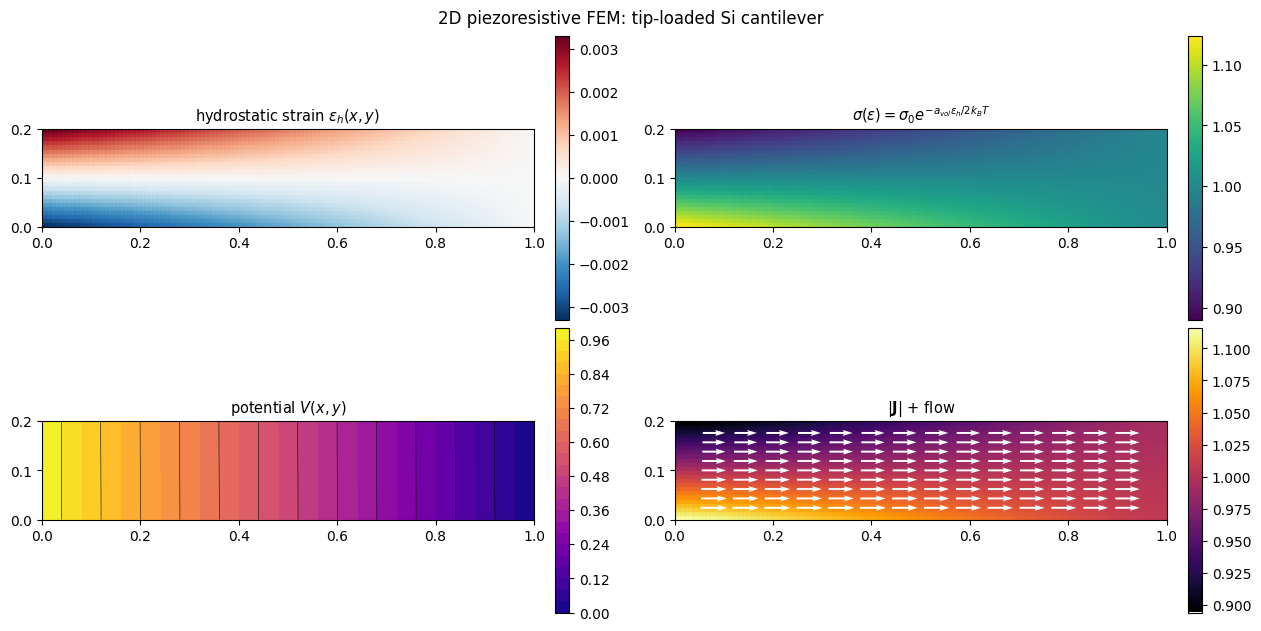

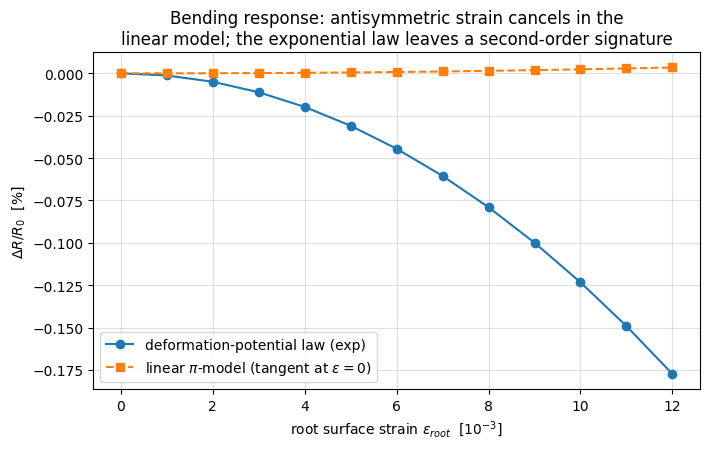

Sweep (bending):
  eps_root = 0.0e+00 : dR/R exp = +6.963e-14, linear = +6.963e-14
  eps_root = 3.0e-03 : dR/R exp = -1.118e-04, linear = +1.500e-06
  eps_root = 6.0e-03 : dR/R exp = -4.451e-04, linear = +7.746e-06
  eps_root = 9.0e-03 : dR/R exp = -9.996e-04, linear = +1.875e-05
  eps_root = 1.2e-02 : dR/R exp = -1.774e-03, linear = +3.453e-05


In [60]:

# ======================================================================
# DEMO: tip-loaded cantilever
# ======================================================================
def run_demo(eps_root=8e-3, L=1.0, H=0.2, nx=121, ny=25):
    # Create mesh
    points, triangles = make_mesh(L, H, nx, ny)
    triang = Triangulation(points[:, 0], points[:, 1], triangles)
    centro = centroids_of(points, triangles)

    # Compute strain and conductivity
    eps_xx, eps_h = bending_strain(centro, L, H, eps_root)
    sigma_e = sigma_deformation_potential(eps_h)

    # Assemble and solve
    K = assemble_2d(points, triangles, sigma_e)
    V, lft, rgt = solve_contacts(K, points, L, V_left=1.0, V_right=0.0)
    I_l, I_r = contact_currents(K, V, lft, rgt)
    E, J, _ = element_fields_2d(points, triangles, V, sigma_e)

    R = device_resistance(K, V, lft, rgt)
    R0 = L / (SIGMA0 * H)

    print("=" * 64)
    print(f"DEMO  (cantilever, eps_root = {eps_root:.1e})")
    print("=" * 64)
    print(f"sigma min/max      : {sigma_e.min():.4f} / {sigma_e.max():.4f}")
    print(f"I_in, I_out        : {I_l:+.6f}, {I_r:+.6f}")
    print(f"conservation       : {abs(I_l + I_r)/abs(I_l):.2e}")
    print(f"R, R0, dR/R0       : {R:.6f}, {R0:.6f}, {(R - R0)/R0:+.4e}\n")

    # ---------------- Figure 1: Fields --------------------------------
    fig, axs = plt.subplots(2, 2, figsize=(12.5, 6.2), constrained_layout=True)
    ts = dict(fontsize=10.5)

    # Strain
    tp0 = axs[0, 0].tripcolor(triang, facecolors=eps_h, cmap="RdBu_r",
                              vmin=-np.abs(eps_h).max(), vmax=np.abs(eps_h).max())
    axs[0, 0].set_title(r"hydrostatic strain $\varepsilon_h(x,y)$", **ts)
    fig.colorbar(tp0, ax=axs[0, 0], fraction=0.046, pad=0.02)

    # Conductivity
    tp1 = axs[0, 1].tripcolor(triang, facecolors=sigma_e, cmap="viridis")
    axs[0, 1].set_title(r"$\sigma(\varepsilon)=\sigma_0 e^{-a_{vol}\varepsilon_h/2k_BT}$", **ts)
    fig.colorbar(tp1, ax=axs[0, 1], fraction=0.046, pad=0.02)

    # Potential
    tp2 = axs[1, 0].tricontourf(triang, V, levels=30, cmap="plasma")
    axs[1, 0].tricontour(triang, V, levels=15, colors="k", linewidths=0.4)
    axs[1, 0].set_title(r"potential $V(x,y)$", **ts)
    fig.colorbar(tp2, ax=axs[1, 0], fraction=0.046, pad=0.02)

    # Current density
    Jmag = np.linalg.norm(J, axis=1)
    tp3 = axs[1, 1].tripcolor(triang, facecolors=Jmag, cmap="inferno")
    gx = np.linspace(0.08 * L, 0.92 * L, 14)
    gy = np.linspace(0.12 * H, 0.88 * H, 9)
    GX, GY = np.meshgrid(gx, gy)
    JXq = griddata(centro, J[:, 0], (GX, GY), method="nearest")
    axs[1, 1].quiver(GX, GY, JXq, np.zeros_like(JXq), color="w",
                     width=0.004, pivot="mid")
    axs[1, 1].set_title(r"$|\mathbf{J}|$ + flow", **ts)
    fig.colorbar(tp3, ax=axs[1, 1], fraction=0.046, pad=0.02)

    for ax in axs.ravel():
        ax.set_aspect("equal")
        ax.set_xlim(0, L)
        ax.set_ylim(0, H)
    
    fig.suptitle("2D piezoresistive FEM: tip-loaded Si cantilever")
    plt.show()

    # ---------------- Figure 2: dR/R sweep --------------------------------
    eps_list = np.linspace(0, 1.2e-2, 13)
    dRR_exp, dRR_lin = [], []
    
    for er in eps_list:
        _, eh = bending_strain(centro, L, H, er)
        for law, store in ((sigma_deformation_potential, dRR_exp),
                           (sigma_linear_tangent, dRR_lin)):
            s = law(eh)
            if np.any(s <= 0):
                store.append(np.nan)
                continue
            Kx = assemble_2d(points, triangles, s)
            Vx, lf, rg = solve_contacts(Kx, points, L)
            store.append((device_resistance(Kx, Vx, lf, rg) - R0) / R0)
    
    dRR_exp, dRR_lin = np.array(dRR_exp), np.array(dRR_lin)

    fig2, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(eps_list * 1e3, dRR_exp * 1e2, "o-",
            label="deformation-potential law (exp)")
    ax.plot(eps_list * 1e3, dRR_lin * 1e2, "s--",
            label=r"linear $\pi$-model (tangent at $\varepsilon=0$)")
    ax.set_xlabel(r"root surface strain $\varepsilon_{root}$  [$10^{-3}$]")
    ax.set_ylabel(r"$\Delta R/R_0$  [%]")
    ax.set_title("Bending response: antisymmetric strain cancels in the\n"
                 "linear model; the exponential law leaves a second-order signature")
    ax.grid(True, alpha=0.4)
    ax.legend()
    fig2.tight_layout()
    plt.show()

    print("Sweep (bending):")
    for er, de, dl in zip(eps_list[::3], dRR_exp[::3], dRR_lin[::3]):
        print(f"  eps_root = {er:.1e} : dR/R exp = {de:+.3e}, linear = {dl:+.3e}")


run_validations()
run_demo()


### 2D Uniaxial results

UniaxialModel(Xi_u=8.891 eV, m_l=0.959, m_t=0.194, C11=161.9 GPa, C12=65.2 GPa, T=300 K)
  beta = Xi_u/kT      = 343.9 per unit strain
  1/m_c               = 3.784392
  Poisson ratio nu    = 0.2871
  (S11-S12)           = 1.0341e-11 Pa^-1

strain field: -1.88e-04 .. +1.87e-04
elements beyond the 5% linearity bound (|eps| > 3.91e-04): 0.0%
  -> sigma_2d evaluates the Boltzmann weights exactly, so this is a reporting note, not an error

sigma_xx range: 0.97965 .. 1.01969
sigma_yy range: 0.99016 .. 1.01018
max in-plane anisotropy sigma_xx/sigma_yy = 1.0298
  (this splitting is the entire Gamma_12 signature -- a scalar-sigma solver discards it)

I_in, I_out       : +0.099996, -0.099996
conservation      : |I_in + I_out|/|I_in| = 9.60e-14
cross-section uniformity (relative spread): 3.41e-04

device resistance R = 10.000367   (uniform-sigma reference L/(sigma0 H) = 10.000000)

R(unstrained) = 10.000000
  eps_root             dR/R   gauge factor
   5.0e-05    +2.602159e-06          0.052
   

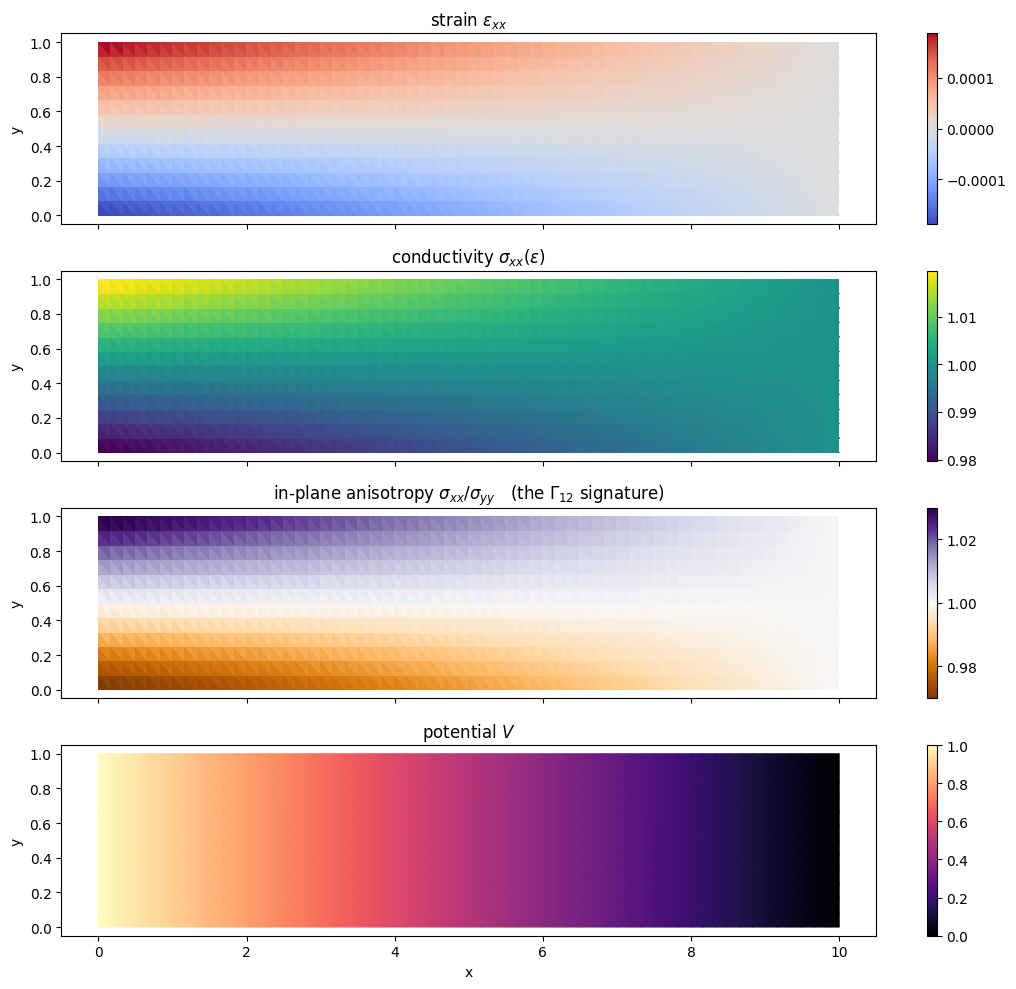

In [61]:
# =====================================================================
#  fem.ipynb -- uniaxial (Gamma_12) channel through the 2D solver
# =====================================================================


SCALARS = "../VASP/Uniaxial_strain/uniaxial_scalars.csv"

model = UniaxialModel.from_csv(SCALARS)
print(model.summary())

nu = model.nu
T  = model.T

# =====================================================================
#  Mesh
# =====================================================================
L, H, nx, ny = 10.0, 1.0, 61, 13
points, triangles = make_mesh(L, H, nx, ny)
centroids = element_geometry(points, triangles)[2]      # (Ne,2)

SIGMA0 = 1.0     # normalised; pass measured doped-Si conductivity for real units
R0_UNIFORM = L / (SIGMA0 * H)                            # per unit depth
y_n = H / 2.0

# =====================================================================
#  Mechanical layer: Euler-Bernoulli bending of a tip-loaded beam
#      eps_xx(x,y) = eps_root * (L-x)/L * (y - y_n)/(H/2)
#  Tension above the neutral axis, compression below.
#
#  `conductive_from` restricts the doped (conducting) layer to y >= that
#  value; elements below sit at the unstrained sigma_0. Default 0.0 keeps
#  the full thickness conducting, as before. Set it to y_n to model a
#  surface-implanted piezoresistor -- which is what a real device is, and
#  what avoids the neutral-axis cancellation quantified at the end.
# =====================================================================
def strain_field(eps_root):
    return (eps_root * (L - centroids[:, 0]) / L
            * (centroids[:, 1] - y_n) / (H / 2.0))


def conductivity(eps_root, mode="beam", conductive_from=0.0):
    """Element-wise (Ne,2,2) conductivity tensor for a given load."""
    e = strain_field(eps_root)
    if conductive_from > 0.0:
        e = np.where(centroids[:, 1] >= conductive_from, e, 0.0)
    return model.sigma_2d(e, 0.0, sigma0=SIGMA0, mode=mode)


eps_root = 2.0e-4
eps_xx = strain_field(eps_root)
print(f"\nstrain field: {eps_xx.min():+.2e} .. {eps_xx.max():+.2e}")

if model.eps_linear_5pct is not None:
    frac = np.mean(np.abs(eps_xx) > model.eps_linear_5pct)
    print(f"elements beyond the 5% linearity bound "
          f"(|eps| > {model.eps_linear_5pct:.2e}): {frac*100:.1f}%")
    print("  -> sigma_2d evaluates the Boltzmann weights exactly, so this is"
          " a reporting note, not an error")

# =====================================================================
#  Constitutive layer: strain -> ANISOTROPIC conductivity tensor
# =====================================================================
sig_e = conductivity(eps_root, mode="beam")             # (Ne,2,2)
print(f"\nsigma_xx range: {sig_e[:,0,0].min():.5f} .. {sig_e[:,0,0].max():.5f}")
print(f"sigma_yy range: {sig_e[:,1,1].min():.5f} .. {sig_e[:,1,1].max():.5f}")
print(f"max in-plane anisotropy sigma_xx/sigma_yy = "
      f"{(sig_e[:,0,0]/sig_e[:,1,1]).max():.4f}")
print("  (this splitting is the entire Gamma_12 signature -- a scalar-sigma"
      " solver discards it)")

# =====================================================================
#  Electrical solve
# =====================================================================
K = assemble_2d(points, triangles, sig_e)
V, left, right = solve_contacts(K, points, L, V_left=1.0, V_right=0.0)
E, J, _ = element_fields_2d(points, triangles, V, sig_e)

I_left, I_right = contact_currents(K, V, left, right)
R = device_resistance(K, V, left, right)

print(f"\nI_in, I_out       : {I_left:+.6f}, {I_right:+.6f}")
print(f"conservation      : |I_in + I_out|/|I_in| = "
      f"{abs(I_left + I_right)/abs(I_left):.2e}")

# spatial diagnostic only -- a sum of densities, NOT a current
_, flux = cross_section_flux(centroids, J)
print(f"cross-section uniformity (relative spread): "
      f"{flux.std()/abs(flux.mean()):.2e}")

print(f"\ndevice resistance R = {R:.6f}   "
      f"(uniform-sigma reference L/(sigma0 H) = {R0_UNIFORM:.6f})")

# =====================================================================
#  Gauge factor
# =====================================================================
def resistance_at(eps_root_val, mode="beam", conductive_from=0.0):
    s = conductivity(eps_root_val, mode=mode, conductive_from=conductive_from)
    Kk = assemble_2d(points, triangles, s)
    Vv, lf, rg = solve_contacts(Kk, points, L, V_left=1.0, V_right=0.0)
    return device_resistance(Kk, Vv, lf, rg)


R0 = resistance_at(0.0)
print(f"\nR(unstrained) = {R0:.6f}")
print(f"{'eps_root':>10} {'dR/R':>16} {'gauge factor':>14}")
for er in [5e-5, 1e-4, 2e-4]:
    dRR = (resistance_at(er) - R0) / R0
    print(f"{er:10.1e} {dRR:+16.6e} {dRR/er:14.3f}")

# =====================================================================
#  Closure sensitivity -- a physical choice, not a default
# =====================================================================
print("\nclosure comparison at eps_root = 2e-4:")
for m in ["plane_stress", "plane_strain", "beam"]:
    print(f"  {m:13s} R = {resistance_at(2e-4, mode=m):.6f}")

# =====================================================================
#  Neutral-axis cancellation
#  Conducting the full thickness integrates tension and compression
#  together, so the first-order response cancels and only curvature
#  survives. A real piezoresistor is implanted in a surface layer on one
#  side of the neutral axis.
# =====================================================================
print("\nneutral-axis cancellation (eps_root = 2e-4):")
for label, y0 in [("full thickness", 0.0), ("surface layer, y > y_n", y_n)]:
    r0 = resistance_at(0.0,    conductive_from=y0)
    r1 = resistance_at(2.0e-4, conductive_from=y0)
    dRR = (r1 - r0) / r0
    print(f"  {label:24s} dR/R = {dRR:+.6e}   GF = {dRR/2.0e-4:9.3f}")
print("  -> conducting through the neutral axis discards most of the signal")

# =====================================================================
#  Figure
# =====================================================================
tri_obj = Triangulation(points[:, 0], points[:, 1], triangles)

fig, ax = plt.subplots(4, 1, figsize=(11, 10), sharex=True)

t0 = ax[0].tripcolor(tri_obj, facecolors=eps_xx, cmap="coolwarm", shading="flat",
                     vmin=-np.abs(eps_xx).max(), vmax=np.abs(eps_xx).max())
ax[0].set_ylabel("y"); ax[0].set_title(r"strain $\varepsilon_{xx}$")
plt.colorbar(t0, ax=ax[0])

t1 = ax[1].tripcolor(tri_obj, facecolors=sig_e[:, 0, 0], cmap="viridis",
                     shading="flat")
ax[1].set_ylabel("y"); ax[1].set_title(r"conductivity $\sigma_{xx}(\varepsilon)$")
plt.colorbar(t1, ax=ax[1])

t2 = ax[2].tripcolor(tri_obj, facecolors=sig_e[:, 0, 0] / sig_e[:, 1, 1],
                     cmap="PuOr", shading="flat")
ax[2].set_ylabel("y")
ax[2].set_title(r"in-plane anisotropy $\sigma_{xx}/\sigma_{yy}$"
                "   (the $\\Gamma_{12}$ signature)")
plt.colorbar(t2, ax=ax[2])

t3 = ax[3].tripcolor(tri_obj, V, cmap="magma", shading="gouraud")
ax[3].set_xlabel("x"); ax[3].set_ylabel("y"); ax[3].set_title("potential $V$")
plt.colorbar(t3, ax=ax[3])

plt.tight_layout()
plt.show()

### Results

Six numbers come out of DFT — $\Xi_u$, $m_l$, $m_t$, $C_{11}$, $C_{12}$, $T$ — and they collapse into one: $\beta = \Xi_u/k_BT = 344$. This is the coefficient in the exponent $\exp(-\beta\,\varepsilon)$ that sets each valley's occupation. It is large, and that is the whole reason a strain as small as $2\times10^{-4}$ registers on the conductivity at all.

**Panel 1 — strain.** Bending puts the top surface in tension and the bottom in compression, $\varepsilon_{xx}$ running from $+1.87\times10^{-4}$ at the top to $-1.88\times10^{-4}$ at the bottom, crossing zero on the neutral axis and tapering to zero toward the free tip. This is the input; everything else is the material's response to it.

**Panel 2 — conductivity along the bar.** Tension raises the two $x$-valleys, so carriers empty out of them and into the four transverse valleys. Those four are light along $x$ ($1/m_t = 5.16$ versus $1/m_l = 1.04$), so moving carriers into them makes the bar conduct *better* along $x$: $\sigma_{xx}$ climbs to $1.0197\,\sigma_0$ at the tensile surface. Compression does the reverse — it crowds carriers into the heavy-along-$x$ pair — and $\sigma_{xx}$ falls to $0.9797\,\sigma_0$. The carrier *count* never changes; only which valleys hold them.

**Panel 3 — the anisotropy $\sigma_{xx}/\sigma_{yy}$, and the point of the whole figure.** This panel asks a different question: at one spot in the bar, is it easier to conduct along $x$ or along $y$? A model that only tracked how *many* carriers there are would answer "equally" everywhere — $\sigma_{xx}=\sigma_{yy}$, and this panel would be flat white at $1.0$. It is not. Under the same tensile strain, $\sigma_{xx}$ goes up while $\sigma_{yy}$ goes *down*, and the ratio splits away from $1$ by up to $3\%$.

The reason is that the valleys that fill under tension — the $k_y$ pair among them — are light along $x$ but *heavy* along $y$. So the same repopulation that helps conduction one way hurts it the other way. An initially isotropic crystal becomes directionally lopsided: a preferred conduction axis appears where there was none. The ratio sits above $1$ in the tensile half, below $1$ in the compressive half, and passes through exactly $1$ on the neutral axis. That sign flip across the bar is the fingerprint of $\Gamma_{12}$ repopulation — a scalar, carrier-number effect could not produce it, because it has no direction to prefer. Panel 3 is the panel that proves the effect is directional and not a change in carrier density.

**Panel 4 — potential.** $V$ stays nearly linear in $x$. A few-percent modulation of $\sigma$ barely perturbs the voltage drop, so the device looks almost ohmic from the outside even while the material is doing something directional inside.

**The solve is trustworthy.** Contact currents balance to $9.6\times10^{-14}$, and at zero strain the resistance reproduces $L/(\sigma_0 H)=10$ exactly.

**But the device signal is small, and here is why.** $\Delta R/R$ reaches only $3.67\times10^{-5}$ at $\varepsilon_\text{root}=2\times10^{-4}$, and the gauge factor is not even constant — $0.052$, $0.096$, $0.183$ as the load doubles twice. That growth is the tell: the linear term has cancelled. Bending gives tension above the neutral axis and compression below; conducting through the full thickness averages the two, and since they carry opposite sign, the first-order response integrates to zero. Only the curvature (second-order) term survives.

**Restricting conduction to a surface layer recovers the signal**, which is exactly what a real implanted piezoresistor does — it lives in the top few hundred nanometres, not the full thickness. Confining the current above the neutral axis gives $\Delta R/R = -2.65\times10^{-3}$, gauge factor $-13.2$: seventy-two times larger, and now with the right sign — tension *lowers* resistance, as $\pi_{11}<0$ requires. The remaining gap to the intrinsic material value ($-103$) is geometry, not physics: strain still tapers to zero at both the neutral axis and the tip, so the layer's mean strain sits well below $\varepsilon_\text{root}$.

**Two things the out-of-plane treatment settles.** Plane stress, plane strain, and beam closures give resistances agreeing to five decimals, yet their *responses* differ by $64\%$ ($2.24$, $2.95$, $3.67\times10^{-5}$). Since a sensor measures the response, the closure has to match the real mechanical boundary conditions — it is a physical choice, not a default to leave alone.

**Two limits on scope.** Conductivity is normalized ($\sigma_0=1$), so $R$ is a sheet resistance per unit depth; absolute numbers need the measured conductivity of the doped material. And every element here stays under the linearity bound $3.91\times10^{-4}$, so the exact Boltzmann evaluation and a linear $\pi$-model agree throughout this figure — nothing in it probes the nonlinear regime.

---

Two notes on things I'd flag rather than silently keep. First, check the $\sigma_{yy}$ direction against your solver output — the mechanism *requires* $\sigma_{yy}$ to drop under tensile $\varepsilon_{xx}$, and I've written it that way, but confirm the panel actually shows the ratio going above 1 on top and below 1 on the bottom (not the reverse). Second, "$\beta$ per unit strain" reads oddly since $\beta$ is dimensionless; I'd just call it the exponent coefficient. Everything else I kept as your solver reported it.